# Predict cluster from RF location (x, y)

Can we predict a neuron's functional cluster from its receptive field location?
We use multinomial logistic regression as a simple linear baseline, then a random forest for comparison.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

RESULTS_DIR = Path(r"C:\Users\MaryBeth\projects\SarvestaniLab\OpenScopeMouseV1\jupyternotebooks\ephys\results")

# --- cluster assignments (unit_id, cluster) ---
cluster_df = pd.read_csv(RESULTS_DIR / "ephys_cluster_assignments.csv")
print(f"Cluster assignments: {cluster_df.shape}")
print(cluster_df.head())

# --- RF info (unit_id, rf_center_x, rf_center_y, r_squared, mouse_name, ...) ---
rf_df = pd.read_csv(RESULTS_DIR / "ephys_rf_unit_info.csv")
print(f"\nRF info: {rf_df.shape}")
print(rf_df[['unit_id', 'rf_center_x', 'rf_center_y', 'rf_r_squared']].head())

Cluster assignments: (20374, 2)
                       unit_id  cluster
0    sub-810531__ProbeA__unit0       11
1    sub-810531__ProbeA__unit1       11
2   sub-810531__ProbeA__unit10       11
3  sub-810531__ProbeA__unit100       10
4  sub-810531__ProbeA__unit101       10

RF info: (20374, 17)
                     unit_id  rf_center_x  rf_center_y  rf_r_squared
0  sub-810531__ProbeA__unit0   -40.000000    -3.615748      0.064796
1  sub-810531__ProbeA__unit1    -8.419615    -1.871524      0.244745
2  sub-810531__ProbeA__unit2   -40.000000     4.499902      0.070324
3  sub-810531__ProbeA__unit3   -33.669531    -5.803703      0.152977
4  sub-810531__ProbeA__unit4    20.714270     9.938263      0.167006


## Merge and prepare features

In [3]:
# Merge cluster labels with RF location
df = cluster_df.merge(
    rf_df[['unit_id', 'rf_center_x', 'rf_center_y', 'rf_r_squared', 'mouse_name']],
    on='unit_id', how='inner'
)
print(f"Merged shape: {df.shape}")
print(f"NaN in rf_center_x: {df['rf_center_x'].isna().sum()}")
print(f"NaN in rf_center_y: {df['rf_center_y'].isna().sum()}")

# Drop units with missing RF location
df = df.dropna(subset=['rf_center_x', 'rf_center_y'])
print(f"After dropping NaN RF: {df.shape}")
print(f"Clusters: {sorted(df['cluster'].unique())}")
print(f"Units per cluster:\n{df['cluster'].value_counts().sort_index()}")

Merged shape: (20374, 6)
NaN in rf_center_x: 2
NaN in rf_center_y: 2
After dropping NaN RF: (20372, 6)
Clusters: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)]
Units per cluster:
cluster
0     2496
1      958
2     2100
3      821
4     2615
5      391
6     1368
7      560
8      969
9      264
10    2709
11     225
12     328
13    2157
14    2411
Name: count, dtype: int64


## Train / test split and fit models

In [4]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    classification_report, confusion_matrix
)

X = df[['rf_center_x', 'rf_center_y']].values
y = df['cluster'].values

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}  Test: {X_test.shape}")

# Scale features (important for logistic regression)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# --- Multinomial logistic regression ---
# class_weight='balanced' handles imbalance by reweighting the loss,
# replacing the SMOTE oversampling step (no imblearn needed)
lr = LogisticRegression(
    solver='lbfgs', max_iter=1000,
    random_state=42, C=1.0,
    class_weight='balanced'
)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

# --- Random forest ---
rf = RandomForestClassifier(
    n_estimators=200, random_state=42, n_jobs=-1,
    class_weight='balanced'
)
rf.fit(X_train_sc, y_train)
y_pred_rf = rf.predict(X_test_sc)

print("\n=== Logistic Regression ===")
print(f"  Accuracy:          {accuracy_score(y_test, y_pred_lr):.3f}")
print(f"  Balanced accuracy: {balanced_accuracy_score(y_test, y_pred_lr):.3f}")

print("\n=== Random Forest ===")
print(f"  Accuracy:          {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"  Balanced accuracy: {balanced_accuracy_score(y_test, y_pred_rf):.3f}")

# Chance level = 1 / n_clusters
n_clusters = len(np.unique(y))
print(f"\nChance level: {1/n_clusters:.3f}  ({n_clusters} clusters)")

Train: (16297, 2)  Test: (4075, 2)

=== Logistic Regression ===
  Accuracy:          0.074
  Balanced accuracy: 0.105

=== Random Forest ===
  Accuracy:          0.142
  Balanced accuracy: 0.115

Chance level: 0.067  (15 clusters)


## Confusion matrices

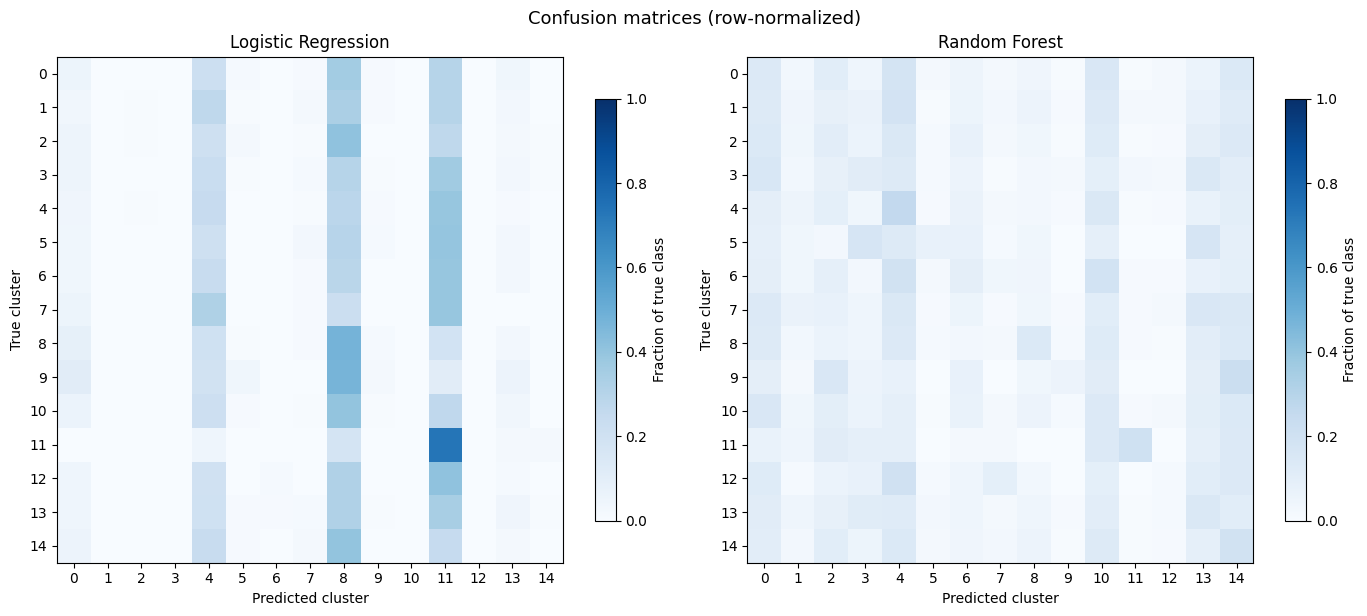

In [5]:
cluster_labels = sorted(np.unique(y))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (y_pred, title) in zip(axes, [
    (y_pred_lr, "Logistic Regression"),
    (y_pred_rf, "Random Forest"),
]):
    cm = confusion_matrix(y_test, y_pred, labels=cluster_labels, normalize='true')
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(len(cluster_labels)))
    ax.set_xticklabels(cluster_labels)
    ax.set_yticks(range(len(cluster_labels)))
    ax.set_yticklabels(cluster_labels)
    ax.set_xlabel("Predicted cluster")
    ax.set_ylabel("True cluster")
    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    ax.set_title(f"{title}")
    plt.colorbar(im, ax=ax, label="Fraction of true class", shrink=0.8)

fig.suptitle("Confusion matrices (row-normalized)", fontsize=13)
fig.tight_layout()
plt.show()

## Decision boundary in RF space (Logistic Regression)

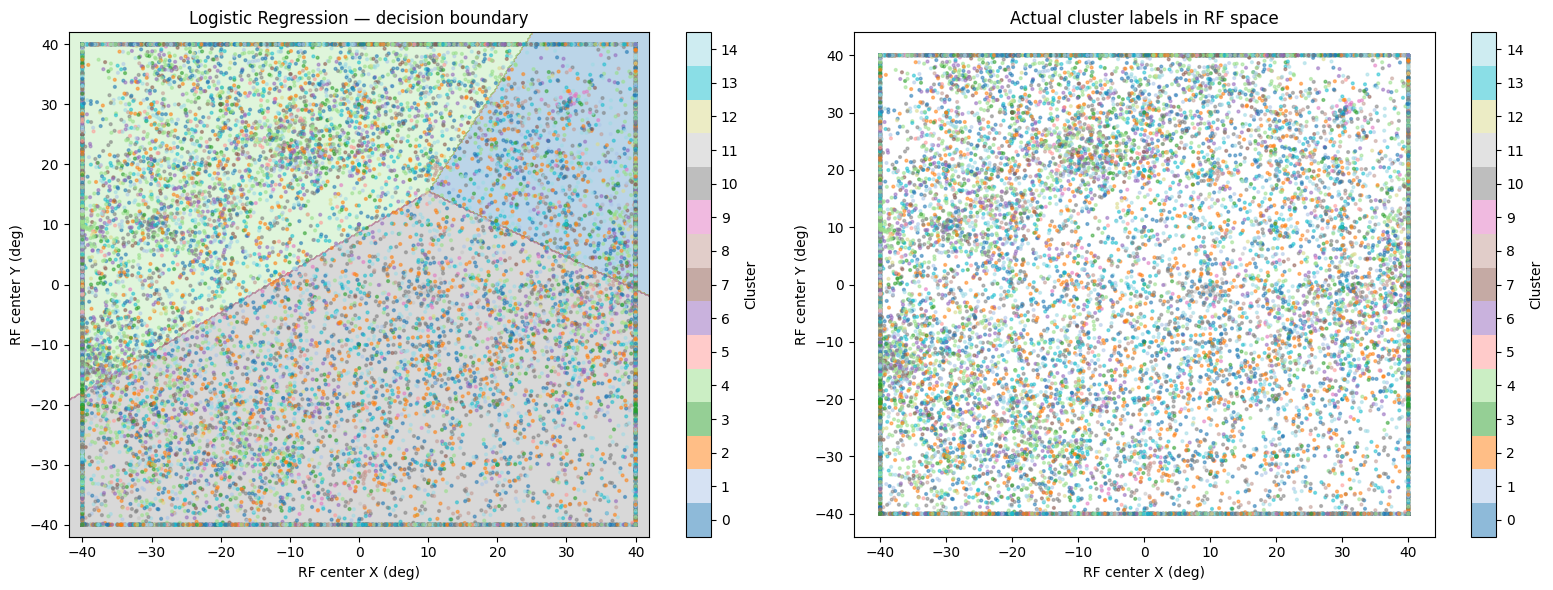

In [8]:
from matplotlib.colors import ListedColormap

# Build a grid over RF space
x_min, x_max = df['rf_center_x'].min() - 2, df['rf_center_x'].max() + 2
y_min, y_max = df['rf_center_y'].min() - 2, df['rf_center_y'].max() + 2
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

grid = scaler.transform(np.c_[xx.ravel(), yy.ravel()])
zz = lr.predict(grid).reshape(xx.shape)

# Cluster colour palette
cmap_clusters = plt.cm.get_cmap('tab20', n_clusters)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: decision boundary ---
ax = axes[0]
ax.contourf(xx, yy, zz, levels=np.arange(-0.5, n_clusters + 0.5, 1),
            cmap=cmap_clusters, alpha=0.3)
sc = ax.scatter(df['rf_center_x'], df['rf_center_y'],
                c=df['cluster'], cmap=cmap_clusters,
                vmin=-0.5, vmax=n_clusters - 0.5,
                s=4, alpha=0.5, rasterized=True)
plt.colorbar(sc, ax=ax, label="Cluster", ticks=cluster_labels)
ax.set_xlabel("RF center X (deg)")
ax.set_ylabel("RF center Y (deg)")
ax.set_title("Logistic Regression — decision boundary")

# --- Right: scatter coloured by cluster, no boundary ---
ax = axes[1]
sc2 = ax.scatter(df['rf_center_x'], df['rf_center_y'],
                 c=df['cluster'], cmap=cmap_clusters,
                 vmin=-0.5, vmax=n_clusters - 0.5,
                 s=4, alpha=0.5, rasterized=True)
plt.colorbar(sc2, ax=ax, label="Cluster", ticks=cluster_labels)
ax.set_xlabel("RF center X (deg)")
ax.set_ylabel("RF center Y (deg)")
ax.set_title("Actual cluster labels in RF space")

fig.tight_layout()
plt.show()

## Per-cluster precision / recall

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (y_pred, title) in zip(axes, [
    (y_pred_lr, "Logistic Regression"),
    (y_pred_rf, "Random Forest"),
]):
    prec, rec, f1, support = precision_recall_fscore_support(
        y_test, y_pred, labels=cluster_labels, zero_division=0
    )
    x = np.arange(len(cluster_labels))
    w = 0.28
    ax.bar(x - w, prec,    width=w, label="Precision", alpha=0.85)
    ax.bar(x,     rec,     width=w, label="Recall",    alpha=0.85)
    ax.bar(x + w, f1,      width=w, label="F1",        alpha=0.85)
    ax.axhline(1 / n_clusters, color='red', linestyle='--', linewidth=1, label='Chance')
    ax.set_xticks(x)
    ax.set_xticklabels(cluster_labels)
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.legend(fontsize=8)

fig.suptitle("Per-cluster precision / recall / F1", fontsize=13)
fig.tight_layout()
plt.show()

## Permutation test — is accuracy above chance?

In [ ]:
from sklearn.model_selection import permutation_test_score

# Use logistic regression for the permutation test (faster than RF)
score, perm_scores, p_value = permutation_test_score(
    LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500, C=1.0),
    X_train_sc, y_train,
    scoring='accuracy',
    cv=5,
    n_permutations=100,
    random_state=42,
    n_jobs=-1,
)

print(f"True CV accuracy:       {score:.3f}")
print(f"Permutation mean acc:   {perm_scores.mean():.3f} ± {perm_scores.std():.3f}")
print(f"p-value:                {p_value:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(perm_scores, bins=20, color='steelblue', alpha=0.8, label='Permuted')
ax.axvline(score, color='red', linewidth=2, label=f'True score={score:.3f}')
ax.axvline(1/n_clusters, color='gray', linestyle='--', label=f'Chance={1/n_clusters:.3f}')
ax.set_xlabel("Accuracy")
ax.set_ylabel("Count")
ax.set_title(f"Permutation test (n=100 permutations, 5-fold CV)\np = {p_value:.4f}")
ax.legend()
fig.tight_layout()
plt.show()